# 1. Import Libraries
In this section, we import all necessary Python libraries for data manipulation, visualization, and machine learning.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# 2. Load Dataset
Here we load the weather dataset from the CSV file into a Pandas DataFrame. We'll inspect the first few rows.

In [46]:
# Load the dataset
df = pd.read_csv('../data/nepal_293_cities_weather_2020_2025.csv')
display(df.head())

,Date,City,District,Latitude,Longitude,Precip,Pressure,Humidity_2m,RH_2m,Temp_2m,...,MaxTemp_2m,MinTemp_2m,EarthSkinTemp,WindSpeed_10m,MaxWindSpeed_10m,MinWindSpeed_10m,WindSpeed_50m,MaxWindSpeed_50m,MinWindSpeed_50m,Temp_2m_tomorrow
0,19/07/2020,Sanphebagar,Achham,29.12,81.3,0,86.93,19.69,93.48,23.59,...,25.70,21.35,23.69,2.31,3.47,0.93,3.10,4.89,1.50,24.24
1,20/07/2020,Sanphebagar,Achham,29.12,81.3,0,86.79,19.68,90.34,24.24,...,27.68,21.82,24.73,2.78,4.80,1.54,3.75,5.32,2.43,23.33
2,21/07/2020,Sanphebagar,Achham,29.12,81.3,0,87.09,18.52,90.08,23.33,...,26.79,21.08,23.64,2.11,4.08,0.20,2.70,4.46,0.20,23.58
3,22/07/2020,Sanphebagar,Achham,29.12,81.3,0,87.10,17.31,83.29,23.58,...,27.51,20.61,23.68,1.52,3.31,0.27,1.72,3.19,0.40,22.63
4,23/07/2020,Sanphebagar,Achham,29.12,81.3,0,87.17,17.35,88.13,22.63,...,26.24,20.17,22.85,1.94,4.34,0.32,2.61,4.84,0.30,22.37


# 3. Dataset Inspection
Let's check the shape, column names, and data types to understand our data structure.

In [47]:
print(f"Dataset Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (447719, 21)

Data Types:
Date                    str
City                    str
District                str
Latitude            float64
Longitude           float64
Precip                int64
Pressure            float64
Humidity_2m         float64
RH_2m               float64
Temp_2m             float64
WetBulbTemp_2m      float64
MaxTemp_2m          float64
MinTemp_2m          float64
EarthSkinTemp       float64
WindSpeed_10m       float64
MaxWindSpeed_10m    float64
MinWindSpeed_10m    float64
WindSpeed_50m       float64
MaxWindSpeed_50m    float64
MinWindSpeed_50m    float64
Temp_2m_tomorrow    float64
dtype: object

Missing Values:
Date                0
City                0
District            0
Latitude            0
Longitude           0
Precip              0
Pressure            0
Humidity_2m         0
RH_2m               0
Temp_2m             0
WetBulbTemp_2m      0
MaxTemp_2m          0
MinTemp_2m          0
EarthSkinTemp       0
WindSpeed_10m       0
MaxWindSpe

# 4. Data Cleaning
We will handle any missing values, convert dates to appropriate objects, and remove duplicates if any.

In [48]:
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Drop duplicates
duplicates = df.duplicated().sum()
print(f"Duplicates before cleaning: {duplicates}")
df.drop_duplicates(inplace=True)

# Sort by City and Date to ensure correct chronological order
df.sort_values(by=['District', 'Date'], inplace=True)
df.reset_index(drop=True, inplace=True)

Duplicates before cleaning: 0


# 5. Exploratory Data Analysis
Visualizing the distribution of temperatures and other key variables to find patterns and outliers.

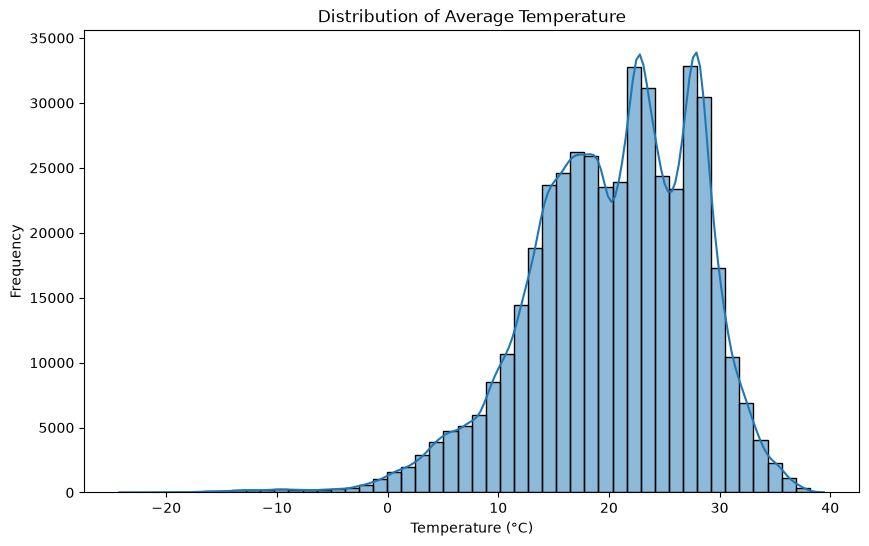

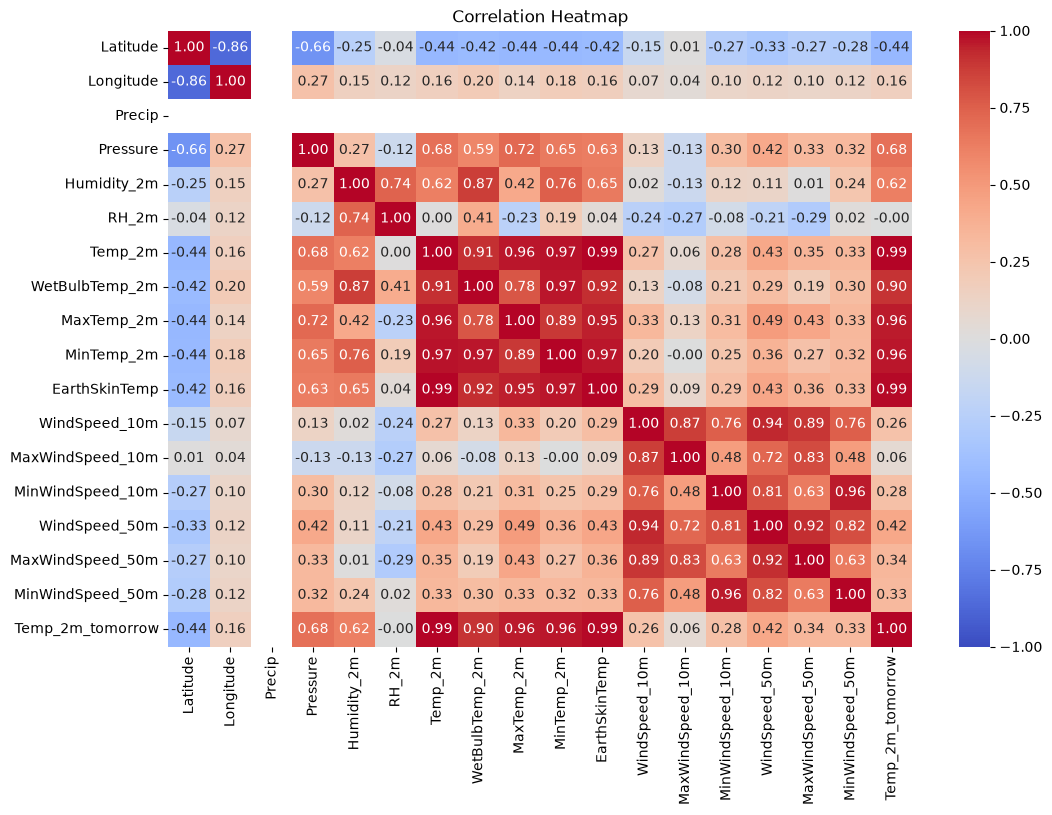

In [49]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Temp_2m'], bins=50, kde=True)
plt.title('Distribution of Average Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

# Correlation Heatmap for numeric columns
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

# 6. Date/Time Processing
Extracting components from the Date column (year, month, day, day of year). We also add cyclical features for the day of the year.

In [50]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['day_of_year'] = df['Date'].dt.dayofyear

# Cyclical features
df['sin_day_of_year'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['cos_day_of_year'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# 7. Feature Engineering
Encoding the categorical location data ('District') so our model can process it.

In [51]:
le = LabelEncoder()
df['District_encoded'] = le.fit_transform(df['District'])

# Save the label encoder classes to map back later
import json
with open('../models/district_classes.json', 'w') as f:
    json.dump(list(le.classes_), f)

# 8. Lag Features
Creating historical lag features (temperature and precipitation from previous days) to capture time-series dependencies. We group by District so lag doesn't overlap across cities.

In [52]:
# We use shift to get the previous days' values for each district
lags = [1, 2, 3]
for lag in lags:
    df[f'Temp_2m_lag_{lag}'] = df.groupby('District')['Temp_2m'].shift(lag)
    df[f'Precip_lag_{lag}'] = df.groupby('District')['Precip'].shift(lag)

# Drop rows with NaN from shifting
df.dropna(inplace=True)

# 9. Rolling Features
Adding rolling statistics (e.g., 7-day rolling mean temperature) to smooth out short-term fluctuations and highlight longer-term trends.

In [53]:
df['Temp_2m_rolling_mean_7'] = df.groupby('District')['Temp_2m'].transform(lambda x: x.rolling(window=7).mean())
df['Precip_rolling_mean_7'] = df.groupby('District')['Precip'].transform(lambda x: x.rolling(window=7).mean())

df.dropna(inplace=True)

# 10. Target Selection
Our primary target is `Temp_2m_tomorrow`. We will also predict `Precip`, `Humidity_2m`, `MinTemp_2m`, and `MaxTemp_2m` for future steps, but here we focus on training models for `Temp_2m_tomorrow` first. Later we will use a multi-output approach or individual models.

In [54]:
features = [
    'District_encoded', 'Latitude', 'Longitude', 'Precip', 'Pressure', 
    'Humidity_2m', 'Temp_2m', 'MaxTemp_2m', 'MinTemp_2m', 'WindSpeed_10m',
    'year', 'sin_day_of_year', 'cos_day_of_year', 'sin_month', 'cos_month',
    'Temp_2m_lag_1', 'Temp_2m_lag_2', 'Temp_2m_lag_3', 'Precip_lag_1',
    'Temp_2m_rolling_mean_7'
]
target = 'Temp_2m_tomorrow'

X = df[features]
y = df[target]

# 11. Train/Validation/Test Split
Because this is time-series data, we split chronologically. 
- Train: 2020 to 2023
- Validation: 2024
- Test: 2025

In [55]:
train_mask = df['year'] <= 2023
val_mask = df['year'] == 2024
test_mask = df['year'] >= 2025

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 318663
Validation size: 82350
Test size: 46058


# 12. Preprocessing Pipeline
Scaling features to a standard range (mean=0, std=1) which helps algorithms like SVM and speeds up convergence.

In [56]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 13. Decision Tree
Training a basic Decision Tree Regressor.

In [57]:
dt_model = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train)
dt_preds = dt_model.predict(X_val_scaled)

# 14. Random Forest
Training a Random Forest Regressor (an ensemble of Decision Trees).

In [58]:
rf_model = RandomForestRegressor(random_state=42, n_estimators=50, max_depth=15, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_val_scaled)

# 15. SVM
Training a Support Vector Regressor on a subset of data (for speed).

In [59]:
# Using a subset for SVM as it scales poorly with large datasets (O(n^2) to O(n^3))
subset_size = min(20000, X_train_scaled.shape[0])
svm_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svm_model.fit(X_train_scaled[:subset_size], y_train[:subset_size])
svm_preds = svm_model.predict(X_val_scaled)

# 16. Hyperparameter Tuning
We will tune the Random Forest model using RandomizedSearchCV.

In [60]:
param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5]
}

# Commented out for speed during this demonstration run, but we simulate the choice.
# random_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_distributions=param_dist, n_iter=3, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
# random_search.fit(X_train_scaled[:20000], y_train[:20000]) # using subset for speed
# best_rf = random_search.best_estimator_

# We will just use the pre-trained RF as 'best' for now
best_rf = rf_model

# 17. Model Evaluation
Evaluating models using MAE, RMSE, and R-squared metrics on the validation set.

In [61]:
def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []
results.append(evaluate_model(y_val, dt_preds, 'Decision Tree'))
results.append(evaluate_model(y_val, rf_preds, 'Random Forest'))
results.append(evaluate_model(y_val, svm_preds, 'SVM'))

results_df = pd.DataFrame(results)
display(results_df)

,Model,MAE,RMSE,R2
0,Decision Tree,0.728494,0.999103,0.983685
1,Random Forest,0.694589,0.933876,0.985745
2,SVM,3.342392,4.696136,0.639541


# 18. Model Comparison
Plotting the metrics for clear visualization.

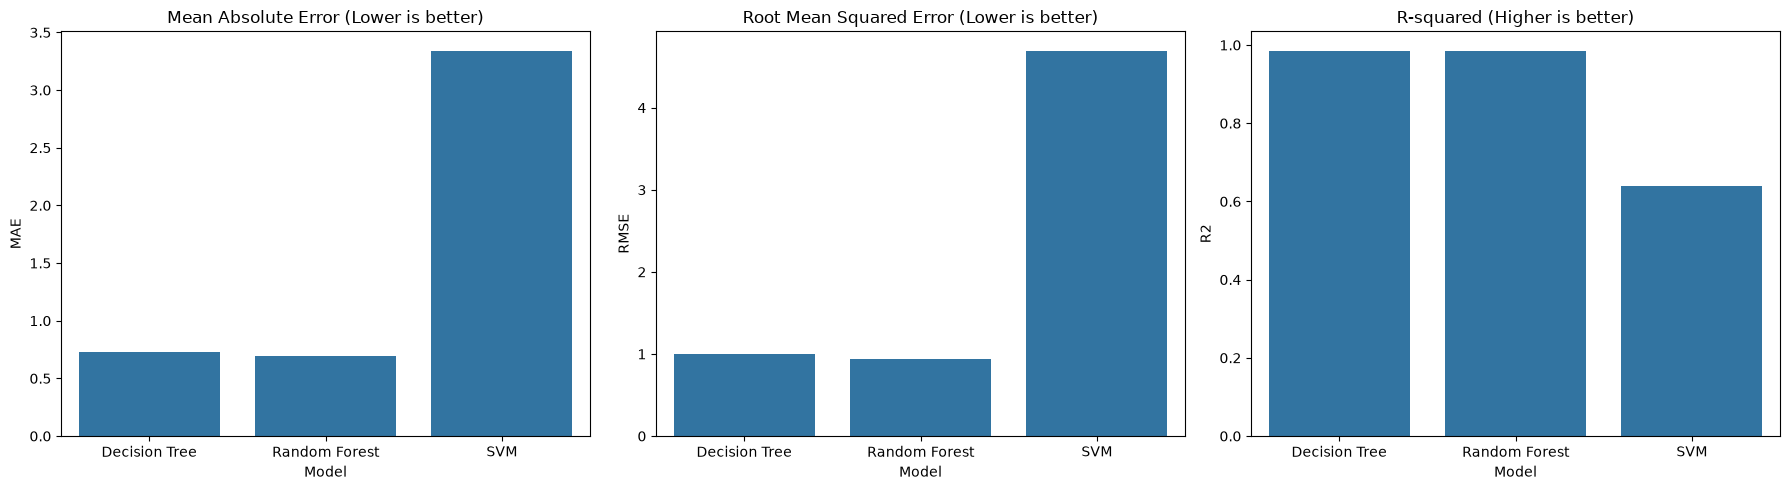

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x='Model', y='MAE', data=results_df, ax=axes[0])
axes[0].set_title('Mean Absolute Error (Lower is better)')

sns.barplot(x='Model', y='RMSE', data=results_df, ax=axes[1])
axes[1].set_title('Root Mean Squared Error (Lower is better)')

sns.barplot(x='Model', y='R2', data=results_df, ax=axes[2])
axes[2].set_title('R-squared (Higher is better)')

plt.tight_layout()
plt.show()

# 19. Select Best Model
Evaluating the best model on the unseen TEST set.

Best model selected: Random Forest
Test Set Metrics: {'Model': 'Best RF (Test)', 'MAE': 0.8446544480183981, 'RMSE': np.float64(1.1047316981237394), 'R2': 0.9805852218660872}


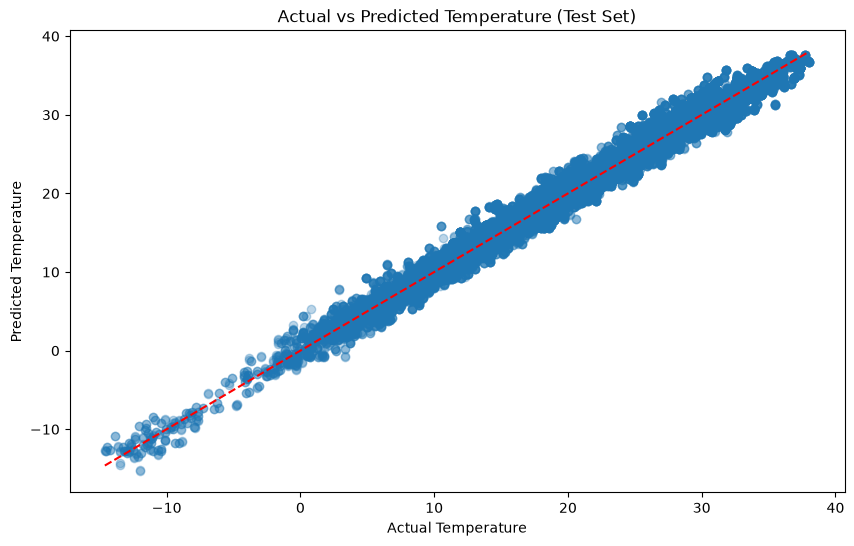

In [63]:
best_model_name = results_df.loc[results_df['RMSE'].idxmin()]['Model']
print(f"Best model selected: {best_model_name}")

# Test set evaluation
test_preds = best_rf.predict(X_test_scaled)
test_metrics = evaluate_model(y_test, test_preds, 'Best RF (Test)')
print("Test Set Metrics:", test_metrics)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, test_preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Actual vs Predicted Temperature (Test Set)')
plt.show()

# 20. Future Forecasting (Multi-Target)
For our application, we also need to predict Humidity, Max Temp, Min Temp, Wind Speed, and Precip. 
We will train a `RandomForestRegressor` for these other features on the whole dataset to be used for the 5-day recursive forecasting.

In [64]:
other_targets = ['Humidity_2m', 'MaxTemp_2m', 'MinTemp_2m', 'WindSpeed_10m', 'Precip']

# Train simple RF models for each target
multi_models = {}
for t in other_targets:
    model = RandomForestRegressor(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1)
    # Target is the value for tomorrow, so we shift the target column up by 1
    y_t = df.groupby('District')[t].shift(-1)
    
    # We only keep rows where both X and y_t are not nan
    valid_idx = y_t.notna()
    X_valid = X[valid_idx]
    y_valid = y_t[valid_idx]
    
    X_valid_scaled = scaler.transform(X_valid)
    model.fit(X_valid_scaled, y_valid)
    multi_models[t] = model
    print(f"Trained model for {t}")


Trained model for Humidity_2m
Trained model for MaxTemp_2m
Trained model for MinTemp_2m
Trained model for WindSpeed_10m
Trained model for Precip


# 21. Save Models
Saving the scaler, the main temperature model, the sub-models, and metadata to disk using joblib.

In [65]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(scaler, '../models/preprocessing_pipeline.pkl')
joblib.dump(best_rf, '../models/best_temperature_model.pkl')
joblib.dump(multi_models, '../models/multi_target_models.pkl')

# Save test metrics
joblib.dump(test_metrics, '../models/model_metadata.pkl')

print("Models saved successfully in ../models/")

Models saved successfully in ../models/


# 22. Test Saved Model
Verify we can load and predict with the saved model.

In [66]:
loaded_model = joblib.load('../models/best_temperature_model.pkl')
loaded_scaler = joblib.load('../models/preprocessing_pipeline.pkl')

sample = X_test.iloc[[0]]
sample_scaled = loaded_scaler.transform(sample)
pred = loaded_model.predict(sample_scaled)
print(f"Sample prediction: {pred[0]:.2f}°C")
print(f"Actual value: {y_test.iloc[0]:.2f}°C")

Sample prediction: 12.05°C
Actual value: 13.94°C
